In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
!pip install -q catboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:000:00:0100:01


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, accuracy_score, f1_score, precision_score, recall_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/samplesuperstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [10]:
df.drop("Row ID", axis=1, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        10194 non-null  object 
 1   Order Date      10194 non-null  object 
 2   Ship Date       10194 non-null  object 
 3   Ship Mode       10194 non-null  object 
 4   Customer ID     10194 non-null  object 
 5   Customer Name   10194 non-null  object 
 6   Segment         10194 non-null  object 
 7   Country/Region  10194 non-null  object 
 8   City            10194 non-null  object 
 9   State/Province  10194 non-null  object 
 10  Postal Code     10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Category        10194 non-null  object 
 14  Sub-Category    10194 non-null  object 
 15  Product Name    10194 non-null  object 
 16  Sales           10194 non-null  float64
 17  Quantity        10194 non-null 

In [12]:
df.describe()

,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


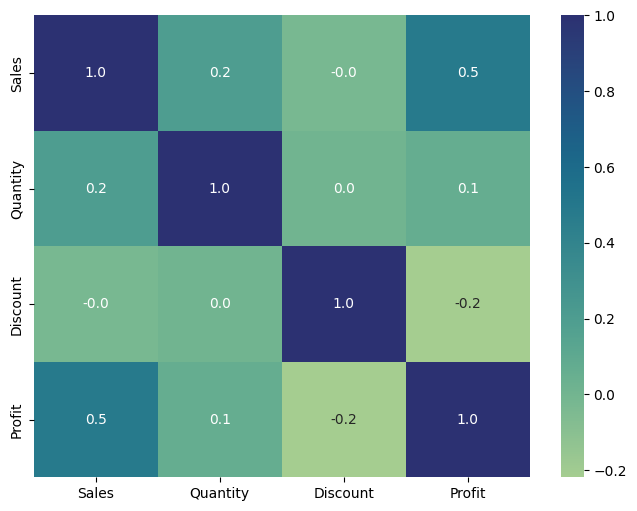

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f", cmap="crest")

plt.show()

In [14]:
TARGET = "profit_class"

class_names = ["Loss", "Low margin", "High margin"]
margin = df["Profit"] / df["Sales"]

df[TARGET] = np.select([df["Profit"] < 0, margin < 0.25], [0, 1], default=2)

In [ ]:
features = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category", "Sales", "Quantity", "Discount"]

df = df[features + [TARGET]].drop_duplicates()
df.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,profit_class
0,Standard Class,Consumer,Central,Office Supplies,Paper,16.448,2,0.2,2
1,Standard Class,Home Office,Central,Office Supplies,Binders,3.540,2,0.8,0
2,Standard Class,Home Office,Central,Office Supplies,Labels,11.784,3,0.2,2
3,Standard Class,Home Office,Central,Office Supplies,Storage,272.736,3,0.2,0
4,Standard Class,Consumer,East,Office Supplies,Art,19.536,3,0.2,2


<Axes: xlabel='profit_class'>

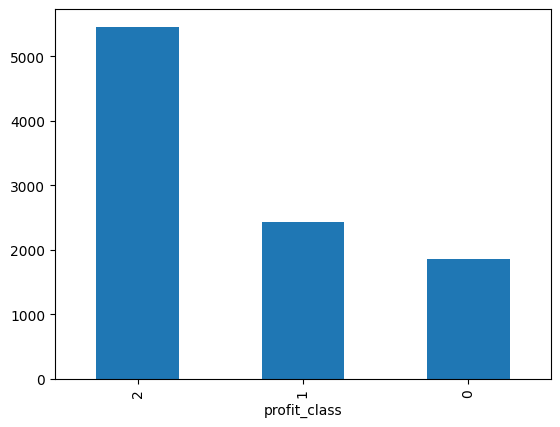

In [18]:
df[TARGET].value_counts().plot(kind="bar")

In [20]:
df[['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']].nunique()

,0
Ship Mode,4
Segment,3
Region,4
Category,3
Sub-Category,17


In [17]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.20, random_state=42
)

In [21]:
for col in X_train.select_dtypes(exclude="number").columns:
    lb = LabelEncoder()
    X_train[col] = lb.fit_transform(X_train[col])
    X_test[col] = lb.transform(X_test[col])
    
X_train.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount
9370,3,0,3,1,3,21.792,4,0.2
7914,0,1,0,1,3,2.304,4,0.8
6521,2,1,1,0,9,13.400,1,0.0
5720,3,0,3,1,3,48.664,7,0.2
6048,1,0,2,0,9,63.968,2,0.2


In [23]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 7805
Testing samples : 1952


In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

print(f"Random Forest | accuracy = {accuracy_score(y_test, rf_pred):.3f}")

Random Forest | accuracy = 0.836


In [26]:
et_model = ExtraTreesClassifier(n_estimators=100, random_state=42)
et_model.fit(X_train, y_train)

et_pred = et_model.predict(X_test)
et_proba = et_model.predict_proba(X_test)

print(f"Extra Trees | accuracy = {accuracy_score(y_test, et_pred):.3f}")

Extra Trees | accuracy = 0.816


In [27]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

print(f"XGBoost | accuracy = {accuracy_score(y_test, xgb_pred):.4f}")

XGBoost | accuracy = 0.8504


In [33]:
lgb_model = LGBMClassifier(n_estimators=150, learning_rate=0.1, max_depth=8, random_state=42)

lgb_model.fit(X_train, y_train)

lgb_pred  = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)

print(f"LightGBM | accuracy = {accuracy_score(y_test, lgb_pred):.4f}")

LightGBM | accuracy = 0.8535


In [35]:
cat_model = CatBoostClassifier(iterations=250, learning_rate=0.1, depth=8, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

cat_pred  = cat_model.predict(X_test).ravel().astype(int)
cat_proba = cat_model.predict_proba(X_test)

print(f"CatBoost | accuracy = {accuracy_score(y_test, cat_pred):.4f}")

CatBoost | accuracy = 0.8422


In [36]:
stack_model = StackingClassifier(
    estimators=[("rf", rf_model), ("cat", cat_model), ("et", et_model), ("xgb", xgb_model),("lgb", lgb_model)],
    
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stack_model.fit(X_train, y_train)
stack_pred  = stack_model.predict(X_test)
stack_proba = stack_model.predict_proba(X_test)

print(f"Stacking | accuracy = {accuracy_score(y_test, stack_pred):.4f}")

Stacking | accuracy = 0.8509


In [39]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "Extra Trees":   (et_pred, et_proba),
    "XGBoost":       (xgb_pred, xgb_proba),
    "LightGBM":      (lgb_pred, lgb_proba),
    "CatBoost":      (cat_pred, cat_proba),
    "Stacking":      (stack_pred, stack_proba),
}

metrics_data = [
    {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (Macro)": precision_score(y_test, pred, average="macro"),
        "Recall (Macro)": recall_score(y_test, pred, average="macro"),
        "F1 (Macro)": f1_score(y_test, pred, average="macro"),
        "Precision (Weighted)": precision_score(y_test, pred, average="weighted"),
        "Recall (Weighted)": recall_score(y_test, pred, average="weighted"),
        "F1 (Weighted)": f1_score(y_test, pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, proba, multi_class="ovr")
    }
    for name, (pred, proba) in models.items()
]

In [40]:
results = pd.DataFrame(metrics_data).sort_values(by="F1 (Macro)", ascending=False).reset_index(drop=True).round(4)

best_model = results.loc[0, "Model"]
results

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),Precision (Weighted),Recall (Weighted),F1 (Weighted),ROC-AUC
0,LightGBM,0.8535,0.8353,0.8283,0.8315,0.8551,0.8535,0.8541,0.9628
1,Stacking,0.8509,0.8372,0.8211,0.8283,0.8533,0.8509,0.8515,0.9633
2,XGBoost,0.8504,0.8379,0.8179,0.8266,0.8529,0.8504,0.8509,0.9617
3,CatBoost,0.8422,0.8241,0.8176,0.8205,0.8443,0.8422,0.8431,0.9596
4,Random Forest,0.8361,0.8172,0.8066,0.8116,0.8367,0.8361,0.8362,0.9537
5,Extra Trees,0.8161,0.7913,0.7846,0.7878,0.8137,0.8161,0.8148,0.9309


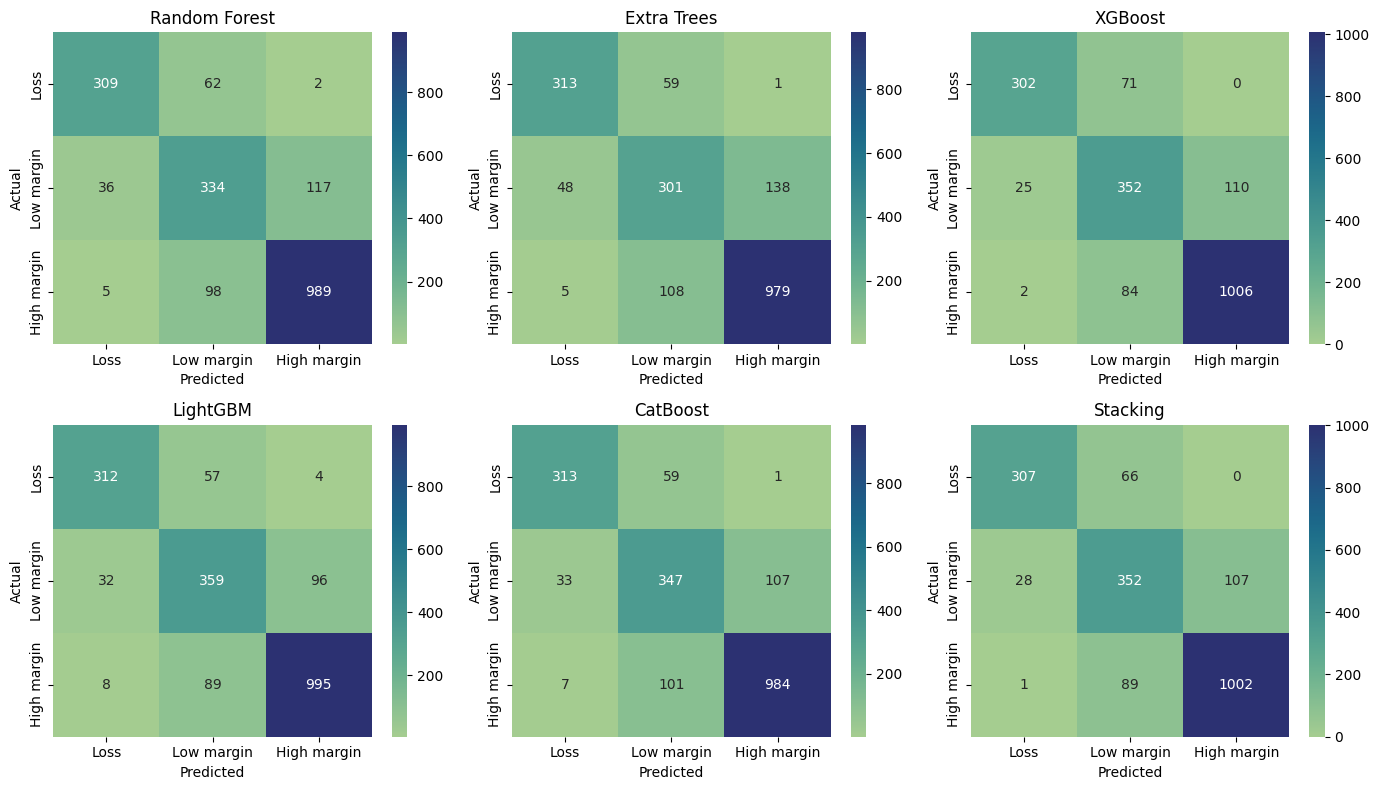

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (name, (pred, proba)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="crest", ax=ax,xticklabels=class_names, yticklabels=class_names)
    
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

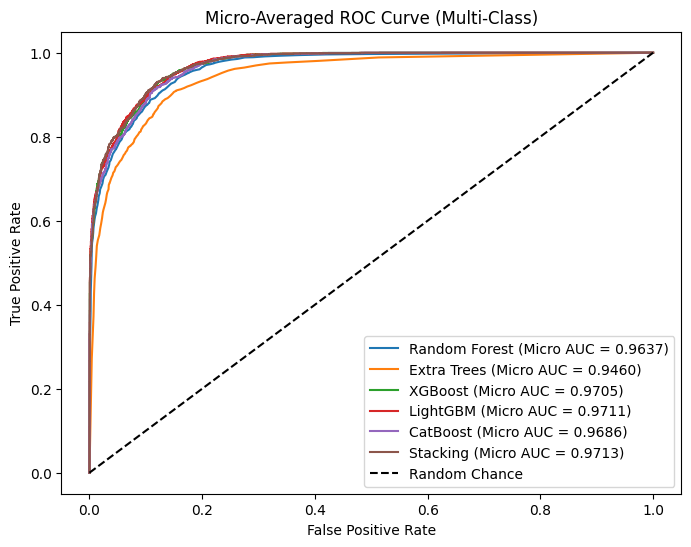

In [ ]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
plt.figure(figsize=(8, 6))

for name, (pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (Micro AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Averaged ROC Curve (Multi-Class)")
plt.legend(loc="lower right")
plt.show()